<a href="https://colab.research.google.com/github/viveksharma-niet/BikeDemandForecastingCaseStudy/blob/main/SimpleLinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd


In [ ]:
advertising = pd.read_csv('https://raw.githubusercontent.com/viveksharma-niet/LinearRegressionUpgrad/refs/heads/main/advertising.csv')

In [ ]:
advertising.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [ ]:
advertising.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [ ]:
advertising.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


# Visivalise the data


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


[]

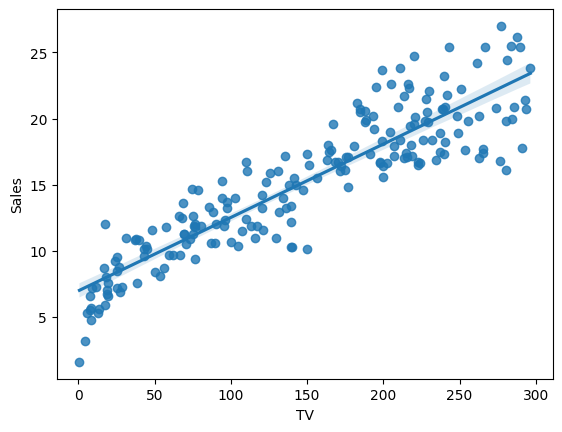

In [ ]:
sns.regplot(x='TV', y='Sales', data=advertising)
plt.plot()

[]

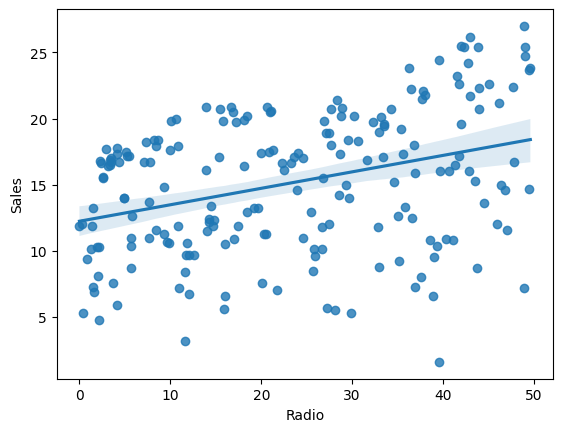

In [ ]:
sns.regplot(x='Radio', y='Sales', data=advertising)
plt.plot()

[]

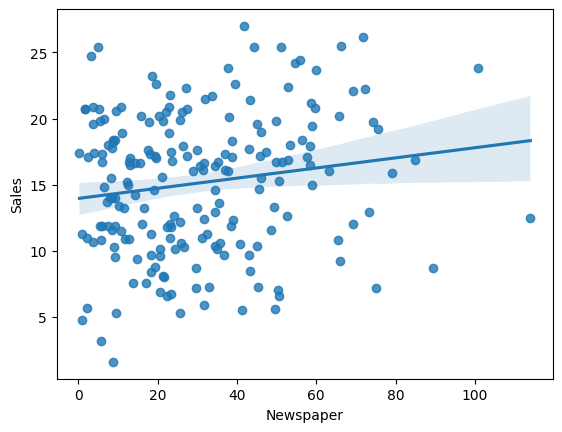

In [ ]:
sns.regplot(x='Newspaper', y='Sales', data=advertising)
plt.plot()

[]

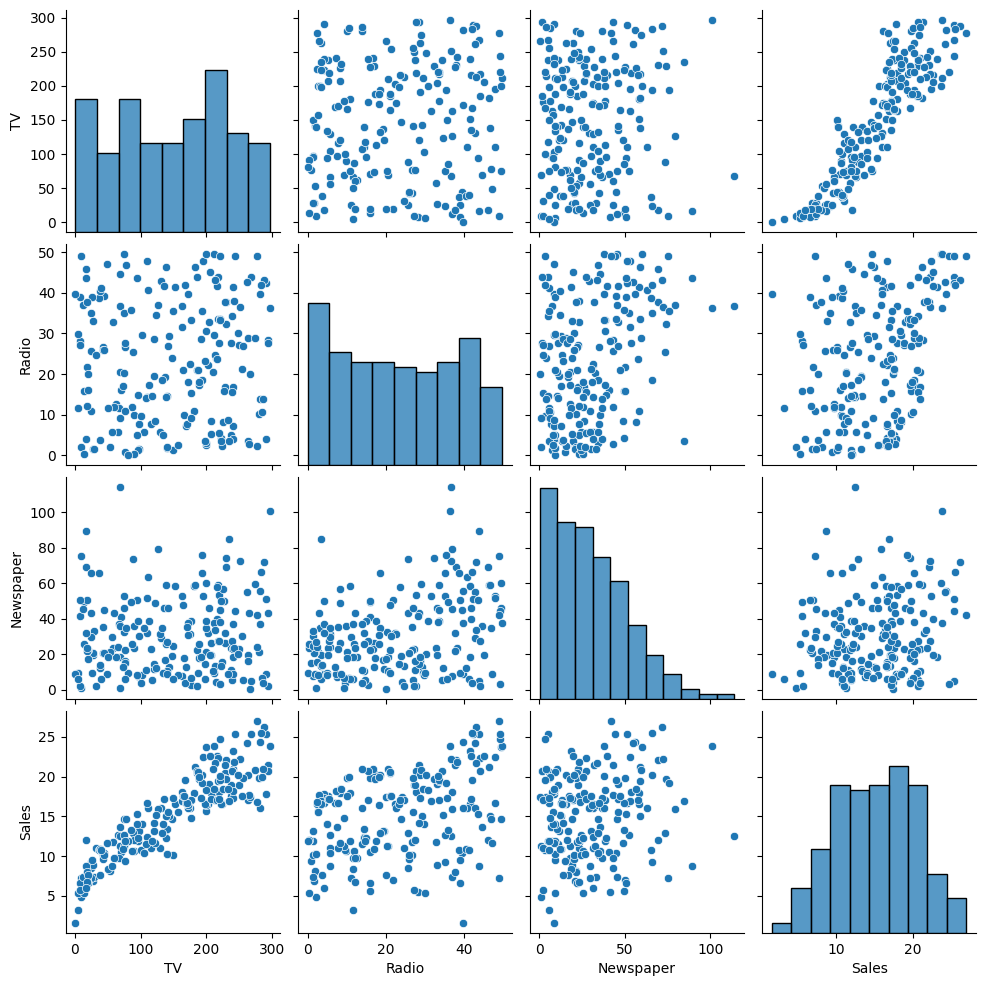

In [ ]:
sns.pairplot(advertising)
plt.plot()

[]

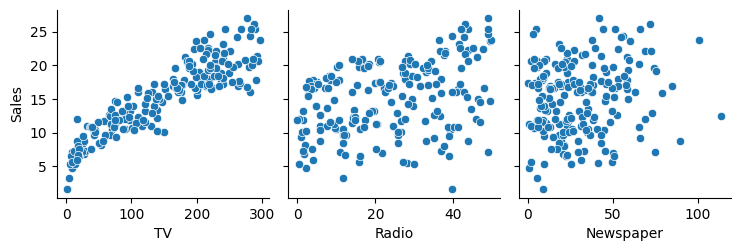

In [ ]:
sns.pairplot(advertising, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales')
plt.plot()

In [ ]:
advertising.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


[]

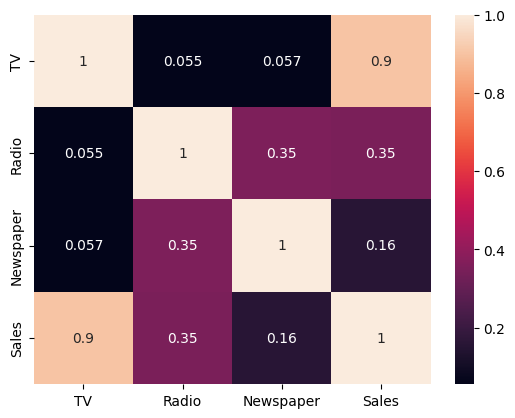

In [ ]:
sns.heatmap(advertising.corr(), annot=True)
plt.plot()

In [ ]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

In [ ]:
X = advertising['TV']
y = advertising['Sales']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=100)


In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((140,), (60,), (140,), (60,))

In [ ]:
import statsmodels.api as sm

In [ ]:
X_train_sm = sm.add_constant(X_train)

In [ ]:
X_train_sm.shape

(140, 2)

In [ ]:
X_train_sm.head()

,const,TV
74,1.0,213.4
3,1.0,151.5
185,1.0,205.0
26,1.0,142.9
90,1.0,134.3


In [ ]:
lr = sm.OLS(y_train, X_train_sm)

In [ ]:
lr_model = lr.fit()

In [ ]:
lr_model.params

,0
const,6.948683
TV,0.054546


In [ ]:
lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     611.2
Date:                Sun, 04 Jan 2026   Prob (F-statistic):           1.52e-52
Time:                        05:29:28   Log-Likelihood:                -321.12
No. Observations:                 140   AIC:                             646.2
Df Residuals:                     138   BIC:                             652.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.9487      0.385     18.068      0.000       6.188       7.709
TV             0.0545      0.002     24.722      0.000       0.050       0.059
==============================================================================
Omnibus:                        0.027   Durbin-Watson:                   2.196
Prob(Omnibus):                  0.987   Jarque-Bera (JB):                0.150
Skew:                          -0.006   Prob(JB):                        0.928
Kurtosis:                       2.840   Cond. No.                         328.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
y_train_pred = lr_model.predict(X_train_sm)

In [ ]:
res = y_train - y_train_pred

<Figure size 640x480 with 0 Axes>

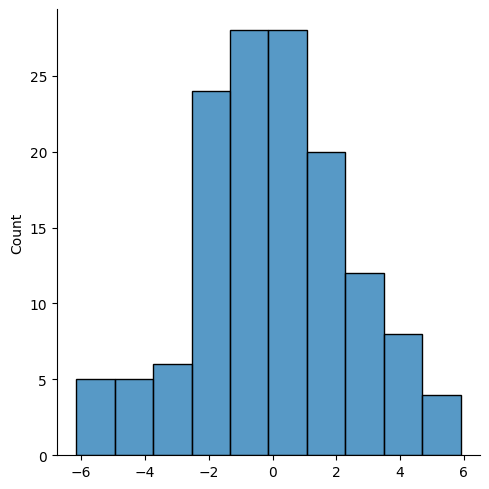

In [ ]:
plt.figure()
sns.displot(res)
plt.show()

## 1. Evaluate the residuals
## 2. Check for patterns in residuals

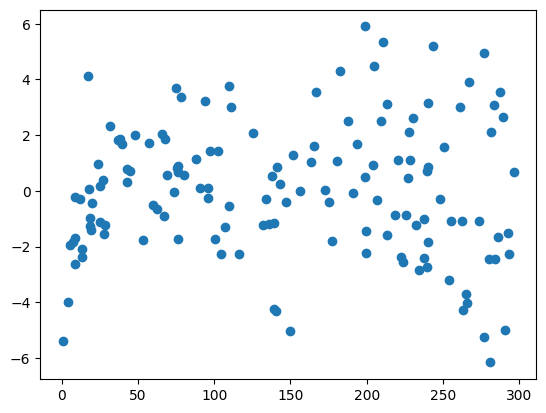

In [ ]:
plt.scatter(X_train, res)
plt.show()

## Predict for the test values

In [ ]:
X_test_sm = sm.add_constant(X_test)

In [ ]:
y_test_pred = lr_model.predict(X_test_sm)

In [ ]:
# import libraries for r2
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error


In [ ]:
r2_pred = r2_score( y_true=y_test, y_pred=y_test_pred)

In [ ]:
r2_pred

0.792103160124566

In [ ]:
r2_train = r2_score(y_true=y_train, y_pred=y_train_pred)
r2_train

0.8157933136480389

In [ ]:
mean_squared_error(y_true=y_test, y_pred=y_test_pred)

4.077556371826953

In [ ]:
mean_squared_error(y_true=y_train, y_pred=y_train_pred)

5.752400386486836


## Linear Regression through SkLearn

In [ ]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=100)

In [ ]:
X_train_lm = X_train.values.reshape(-1, 1)
X_test_lm = X_test.values.reshape(-1, 1)

In [ ]:
lm.fit(X_train_lm, y_train)

LinearRegression()

In [ ]:
lm.coef_

array([0.05454575])

In [ ]:
lm.intercept_

np.float64(6.948683200001357)

In [ ]:
y_test_pred = lm.predict(X_test_lm)
y_train_pred = lm.predict(X_train_lm)

In [ ]:
r2_test = r2_score(y_true=y_test, y_pred=y_test_pred)
r2_train = r2_score(y_true= y_train, y_pred=y_train_pred)

In [ ]:
print(r2_test, r2_train)

0.7921031601245662 0.8157933136480389
